In [101]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import griddata
import numpy as np
import os
from scipy.interpolate import griddata
from scipy.spatial import cKDTree
from tqdm import tqdm

In [67]:
# df = pd.read_csv("flow_past_cylinder/Re_43.5.csv", index_col=0)
df = pd.read_csv("Backward_Facing_Step/Re_2.csv")
df = df[df["x"] <= 0.35]
df

,x,y,u (m/s),v (m/s),p (Pa)
0,0.000000,0.018642,0.000039,-5.695921e-09,1.000506
1,0.001157,0.018959,0.000030,-3.272806e-08,1.000505
2,0.000000,0.019388,0.000018,-2.586939e-09,1.000507
3,0.000000,0.001288,0.000037,5.907195e-09,1.000506
4,0.000000,0.000585,0.000017,2.908707e-10,1.000508
...,...,...,...,...,...
13918,0.347209,0.040000,0.000000,0.000000e+00,1.000226
13919,0.348605,0.039739,0.000002,2.092286e-10,1.000225
13920,0.348605,0.040000,0.000000,0.000000e+00,1.000225
13921,0.350000,0.039734,0.000002,5.232680e-11,1.000225


In [81]:
x = df["x"].values
y = df["y"].values
u = df["u (m/s)"].values
v = df["v (m/s)"].values
p = df["p (Pa)"].values

# Scale factor so that x spans [0, 1]
scale = x.max() - x.min()

x_scaled = (x - x.min()) / scale
y_scaled = (y - y.min()) / scale  


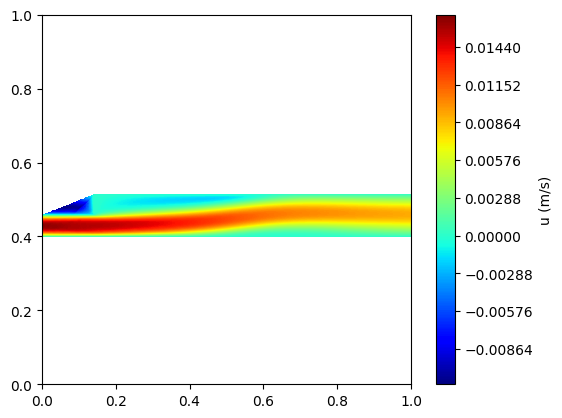

In [82]:
x = df["x"].values
y = df["y"].values
u = df["u (m/s)"].values
v = df["v (m/s)"].values
p = df["p (Pa)"].values

valid = (
    ~np.isnan(x) &
    ~np.isnan(y) &
    ~np.isnan(u) &
    ~np.isnan(v) &
    ~np.isnan(p)
)

x = x[valid]
y = y[valid]
u = u[valid]
v = v[valid]
p = p[valid]

# Scale factor so that x spans [0, 1]
scale = x.max() - x.min()

x_scaled = (x - x.min()) / scale
y_scaled = (y - y.min()) / scale   # Same scale factor preserves aspect ratio

# Create grid
xi = np.linspace(0, 1, 500)
yi = np.linspace(0, 1, 500)

X, Y = np.meshgrid(xi, yi)

# Interpolate
U = griddata((x_scaled, y_scaled+0.4), u, (X, Y), method="cubic")
V = griddata((x_scaled, y_scaled+0.4), v, (X, Y), method="cubic")

# Plot
# plt.figure(figsize=(8, 4))
plt.contourf(X, Y, U, levels=500, cmap="jet")
plt.colorbar(label="u (m/s)")

# plt.scatter(x_scaled, y_scaled+0.4)


plt.xlim(0, 1)
plt.ylim(0, 1)

plt.gca().set_aspect("equal")
plt.show()

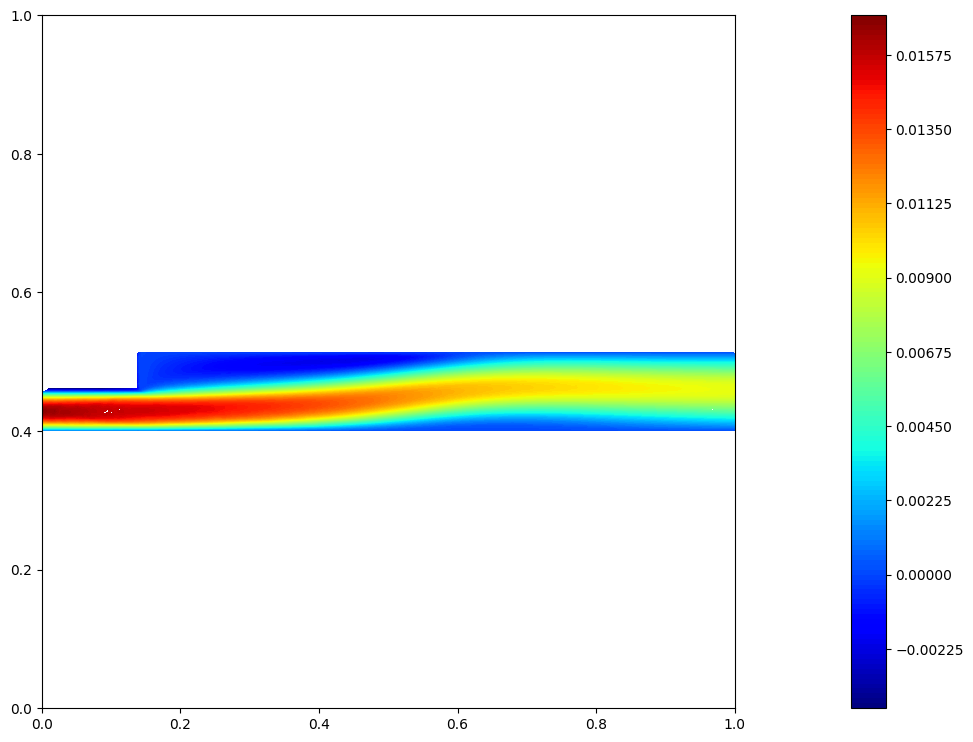

In [86]:
# Interpolate
U = griddata((x_scaled, y_scaled + 0.4), u, (X, Y), method="cubic")
V = griddata((x_scaled, y_scaled + 0.4), v, (X, Y), method="cubic")

# Build KD-tree from original points
tree = cKDTree(np.c_[x_scaled, y_scaled + 0.4])

# Distance from every grid point to nearest original point
dist, _ = tree.query(np.c_[X.ravel(), Y.ravel()])

# Reshape
dist = dist.reshape(X.shape)

# Mask points farther than a threshold
threshold = 0.005      # Adjust as needed
mask = dist > threshold

U = np.ma.masked_where(mask, U)
V = np.ma.masked_where(mask, V)

plt.figure(figsize=(10*3, 3*3))
plt.contourf(X, Y, U, levels=200, cmap="jet")
plt.colorbar()
plt.gca().set_aspect("equal")

plt.xlim(0, 1)
plt.ylim(0, 1)

plt.show()

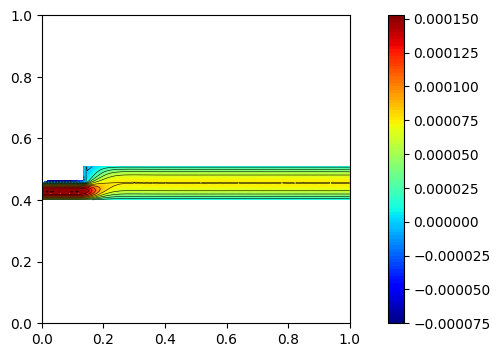

In [64]:
plt.figure(figsize=(10, 4))

cf = plt.contourf(X, Y, U, levels=100, cmap="jet")
plt.colorbar(cf)

# Contour lines
plt.contour(
    X, Y, U,
    levels=20,
    colors="black",
    linewidths=0.4
)

# Velocity arrows
step = 15
plt.quiver(
    X[::step, ::step],
    Y[::step, ::step],
    U[::step, ::step],
    V[::step, ::step],
    color="white",
    scale=20
)

plt.gca().set_aspect("equal")
plt.show()

In [128]:
folder = "flow_past_cylinder"
files = os.listdir(folder)
for file in tqdm(files):
    if file.endswith(".csv"):
        re = file.split("Re_")[-1].split(".csv")[0]

        df = pd.read_csv(f"{folder}/Re_{re}.csv")
        # df = df[df["x"] <= 0.35]

        x = df["x"].values
        y = df["y"].values
        u = df["u (m/s)"].values
        v = df["v (m/s)"].values
        p = df["p (Pa)"].values

        valid = (
            ~np.isnan(x) &
            ~np.isnan(y) &
            ~np.isnan(u) &
            ~np.isnan(v) &
            ~np.isnan(p)
        )

        x = x[valid]
        y = y[valid]
        u = u[valid]
        v = v[valid]
        p = p[valid]

        # Scale factor so that x spans [0, 1]
        scale = x.max() - x.min()

        x_scaled = (x - x.min()) / scale
        y_scaled = (y - y.min()) / scale  

        xi = np.linspace(0, 1, 64)
        yi = np.linspace(0, 1, 64)

        X, Y = np.meshgrid(xi, yi)

        U = griddata((x_scaled, y_scaled+0.4), u, (X, Y), method="cubic")
        V = griddata((x_scaled, y_scaled+0.4), v, (X, Y), method="cubic")
        P = griddata((x_scaled, y_scaled+0.4), p, (X, Y), method="cubic")

        # Build KD-tree from original points
        tree = cKDTree(np.c_[x_scaled, y_scaled + 0.4])

        # Distance from every grid point to nearest original point
        dist, _ = tree.query(np.c_[X.ravel(), Y.ravel()])

        # Reshape
        dist = dist.reshape(X.shape)

        # Mask points farther than a threshold
        threshold = 0.01      # Adjust as needed
        mask = dist > threshold

        U = np.ma.masked_where(mask, U)
        V = np.ma.masked_where(mask, V)
        P = np.ma.masked_where(mask, P)

        mask = ~mask


        new_df = pd.DataFrame({
                                "x": X.flatten(),
                                "y": Y.flatten(),
                                "u (m/s)": U.flatten(),
                                "v (m/s)": V.flatten(),
                                "p (Pa)" : P.flatten(),
                                "mask"   : mask.flatten()
                            })

        # plt.contourf(X, Y, U, levels=100, cmap="jet")
        # plt.colorbar(label="u (m/s)")

        # break

        new_df.to_csv(f"{folder}_domain/Re_{re}.csv")

100%|██████████| 89/89 [00:09<00:00,  9.83it/s]


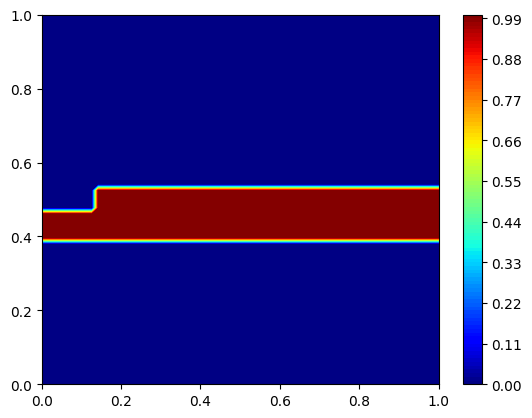

In [122]:
plt.contourf(X, Y, mask, levels=100, cmap="jet")
plt.colorbar()

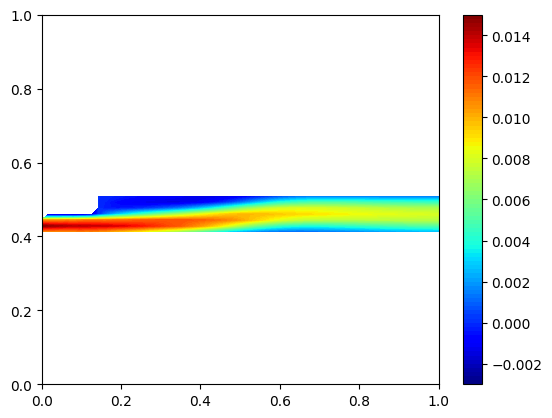

In [112]:
df = pd.read_csv("Backward_Facing_Step_domain/Re_196.csv", index_col=0)

n = 64

X = df["x"].to_numpy().reshape(n, n)
Y = df["y"].to_numpy().reshape(n, n)

U = df["u (m/s)"].to_numpy().reshape(n, n)
V = df["v (m/s)"].to_numpy().reshape(n, n)
P = df["p (Pa)"].to_numpy().reshape(n, n)

mask = df["mask"].to_numpy().reshape(n, n)

a = plt.contourf(X, Y, U, levels=100, cmap="jet")
plt.colorbar(a)

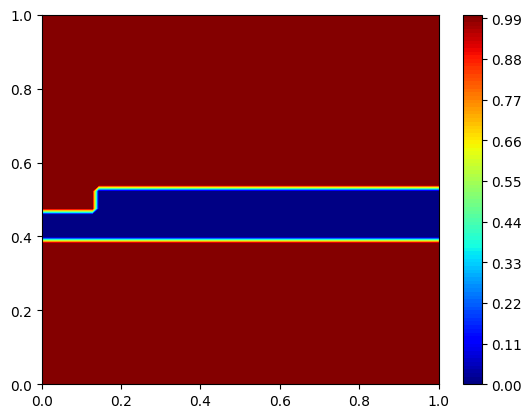

In [113]:
a = plt.contourf(X, Y, mask, levels=100, cmap="jet")
plt.colorbar(a)

In [ ]:
# df = pd.read_csv("flow_past_cylinder/Re_1.5.csv", index_col=0)
df = pd.read_csv("Backward_Facing_Step_domain/Re_222.csv", index_col=0)

df = new_df
x = df["x"].values
y = df["y"].values
u = df["u (m/s)"].values
v = df["v (m/s)"].values
p = df["p (Pa)"].values

# Scale factor so that x spans [0, 1]
scale = x.max() - x.min()

x_scaled = (x - x.min()) / scale
y_scaled = (y - y.min()) / scale  

xi = np.linspace(0, 1, 300)
yi = np.linspace(0, 1, 300)

X, Y = np.meshgrid(xi, yi)
U = griddata((x_scaled[mask], y_scaled[mask]+0.4), u, (X, Y), method="cubic")
V = griddata((x_scaled[mask], y_scaled[mask]+0.4), v, (X, Y), method="cubic")
P = griddata((x_scaled[mask], y_scaled[mask]+0.4), p, (X, Y), method="cubic")


new_df = pd.DataFrame({
                        "x": X.flatten(),
                        "y": Y.flatten(),
                        "u (m/s)": U.flatten(),
                        "v (m/s)": V.flatten(),
                        "p (Pa)" : P.flatten(),
                        "p (Pa)" : P.flatten(),
                    })

plt.contourf(X, Y, U, levels=100, cmap="jet")
plt.colorbar(label="u (m/s)")

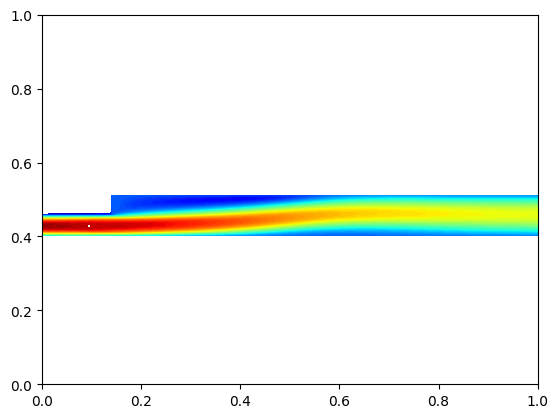

In [104]:
# Create grid
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

newer_df = pd.read_csv("Backward_Facing_Step_domain/Re_188.csv", index_col=0)
n = 300

x = newer_df["x"].values
y = newer_df["y"].values
u = newer_df["u (m/s)"].values

X = newer_df["x"].to_numpy().reshape(n, n)
Y = newer_df["y"].to_numpy().reshape(n, n)

U = newer_df["u (m/s)"].to_numpy().reshape(n, n)
V = newer_df["v (m/s)"].to_numpy().reshape(n, n)
P = newer_df["p (Pa)"].to_numpy().reshape(n, n)


mask = newer_df["mask"].to_numpy().reshape(n, n)

# Plot
# plt.figure(figsize=(8, 4))
plt.contourf(X, Y, U, levels=100, cmap="jet")

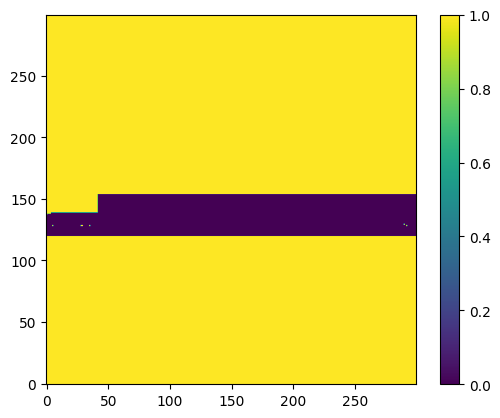

In [ ]:
plt.imshow(np.isnan(P), origin="lower")
plt.colorbar()